In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import plotly.express as px

In [158]:
df = pd.read_csv("diabetes.csv")

In [159]:
df.keys()

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [160]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [161]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [162]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [163]:
cols = ['BloodPressure','SkinThickness','Insulin' , 'BMI']
df[cols] = df[cols].replace(0 , np.nan)

In [164]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

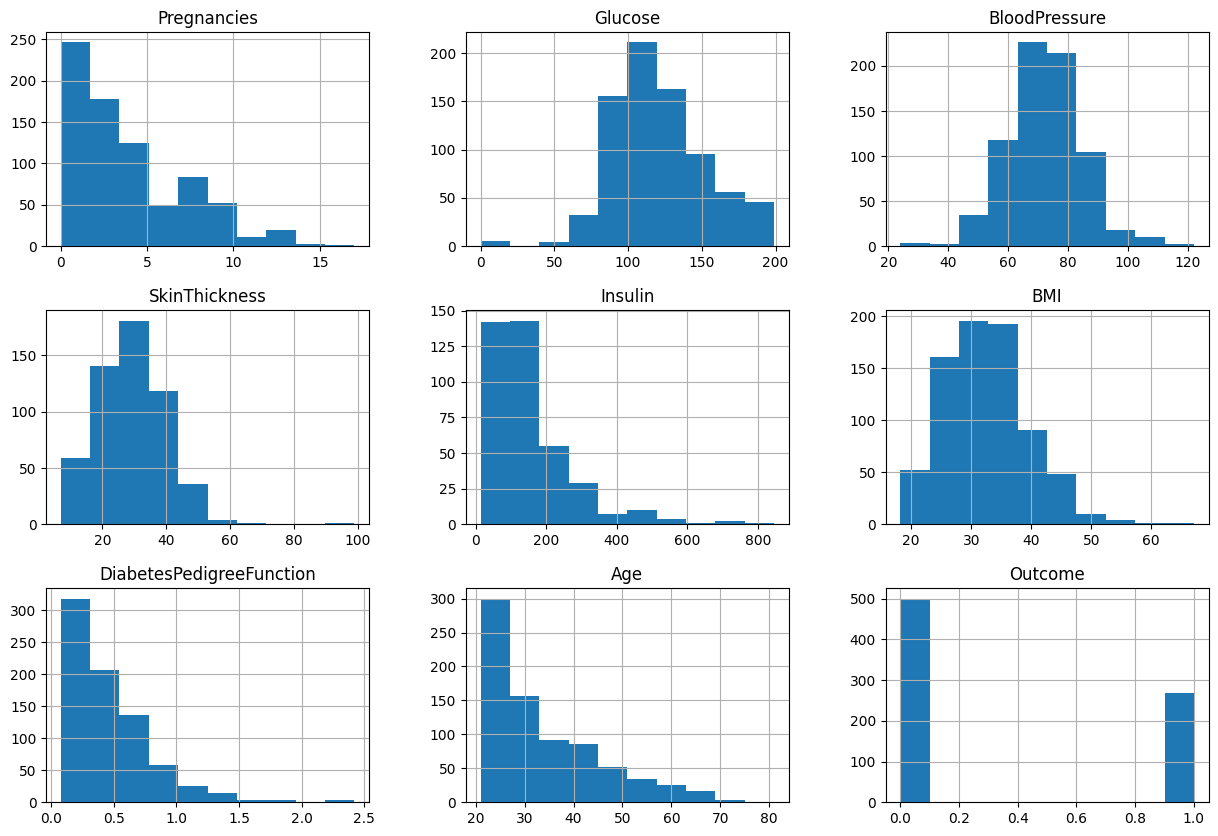

In [165]:
df.hist(figsize=(15,10))
plt.show()

<Axes: >

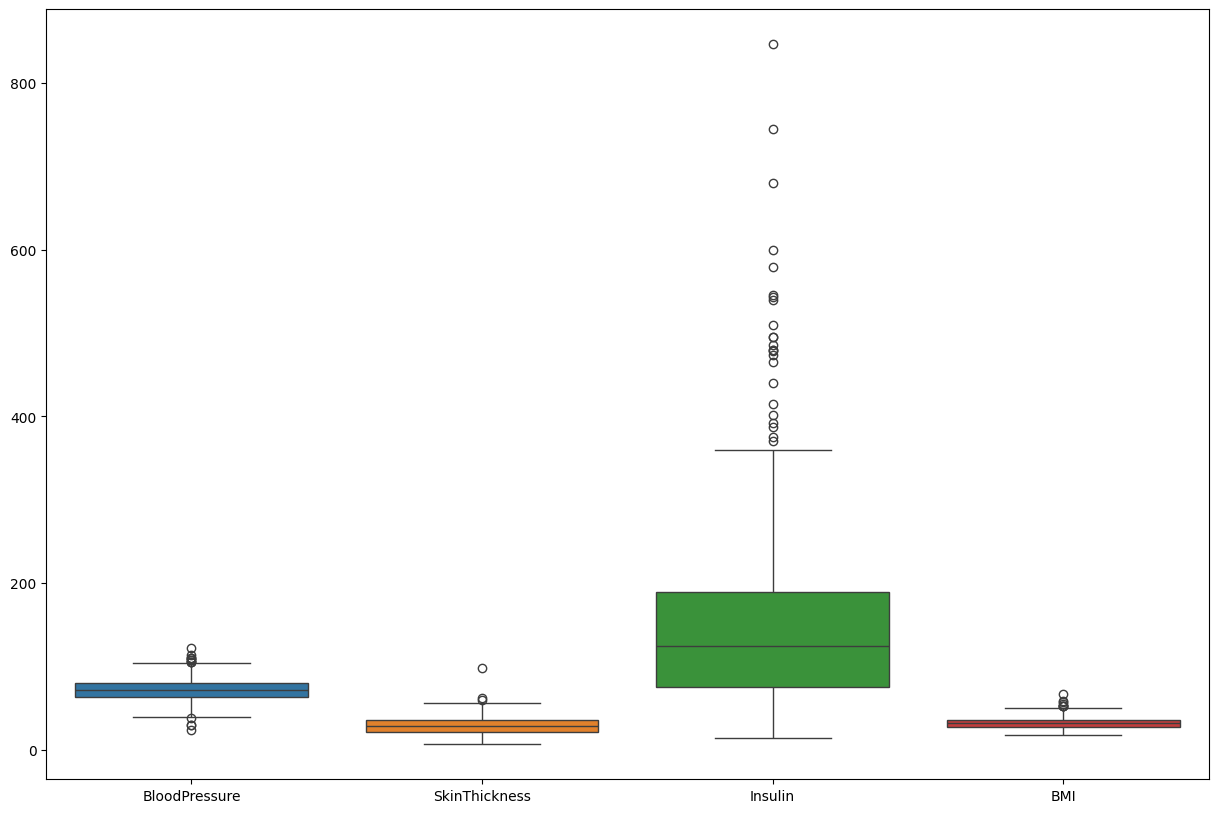

In [166]:
plt.figure(figsize = (15,10))
sns.boxplot(df[cols])

In [167]:
for col in cols:
    df[cols] = df[cols].fillna(df[col].median())

In [168]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [169]:
X = df.drop("Outcome", axis =1)
y = df['Outcome']

In [170]:
from sklearn.linear_model import Perceptron

In [171]:
from sklearn.preprocessing import StandardScaler

In [172]:
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

p = Perceptron(random_state=42)

p.fit(X_train, y_train)

y_pred = p.predict(X_test)

In [173]:
p.coef_

array([[ 0.52639686,  3.96311074, -1.46990977,  0.51697044, -2.22143918,
         4.10756811,  3.11127105, -0.70408805]])

In [174]:
p.intercept_

array([-1.])

In [175]:
pd.DataFrame({"Features":X.columns , "Weights": p.coef_[0]})

,Features,Weights
0,Pregnancies,0.526397
1,Glucose,3.963111
2,BloodPressure,-1.469910
3,SkinThickness,0.516970
4,Insulin,-2.221439
5,BMI,4.107568
6,DiabetesPedigreeFunction,3.111271
7,Age,-0.704088


In [176]:
y_pred = p.predict(X_test)

In [177]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy Score: " ,accuracy_score(y_test,y_pred), end = "\n\n")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred), end = "\n\n")
print("Classfication Report", classification_report(y_test,y_pred), end = "\n\n")

Accuracy Score:  0.7077922077922078

Confusion Matrix: [[70 29]
 [16 39]]

Classfication Report               precision    recall  f1-score   support

           0       0.81      0.71      0.76        99
           1       0.57      0.71      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154




In [178]:
## USING PCA

In [179]:
from sklearn.decomposition import PCA

In [180]:
pca = PCA(n_components = 2)

In [181]:
X_train_pca = pca.fit_transform(X_scaled)
X_test_pca = scaler.transform(X_test)

C:\Users\PC\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [182]:
X_train_pca.shape

(768, 2)

In [183]:
print(pca.explained_variance_ratio_)

[0.26035455 0.18993684]


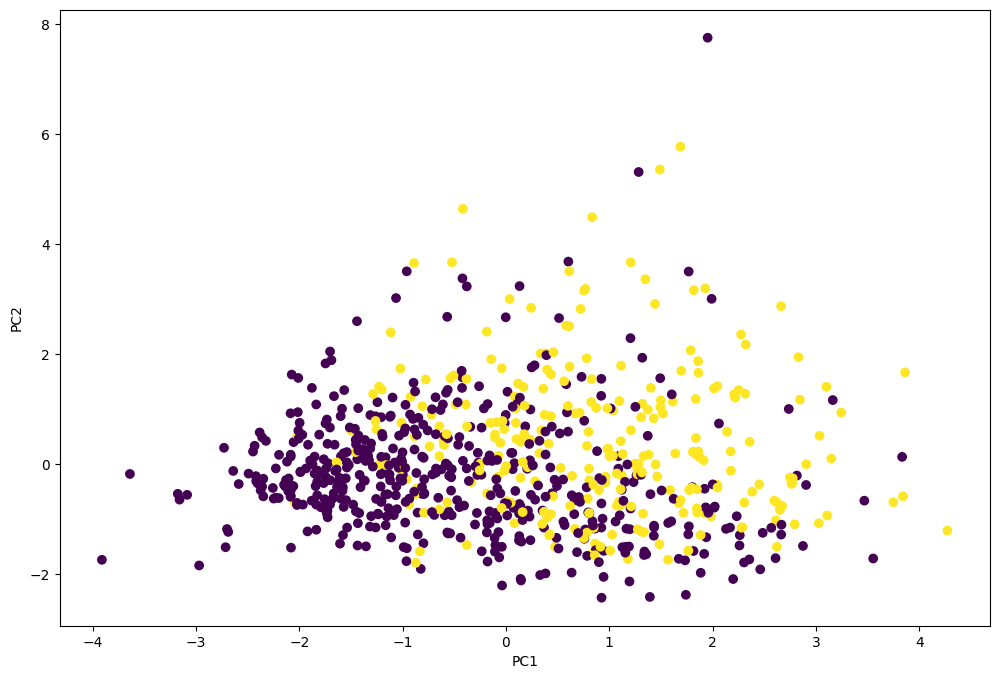

In [184]:
plt.figure(figsize = (12,8))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c = y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [185]:
from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [186]:
pca_model = Perceptron()

pca_model.fit(X_train_pca, y_train)

y_pred = pca_model.predict(X_test_pca)

In [187]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6428571428571429


<Axes: >

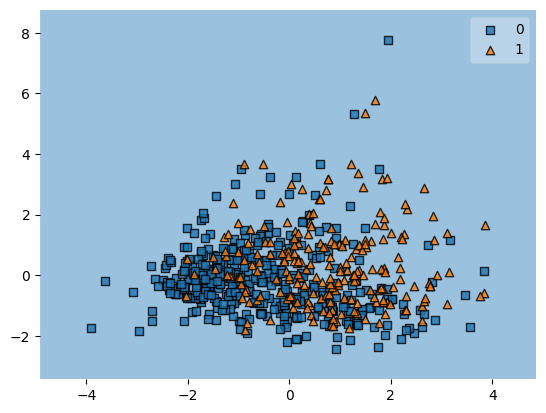

In [188]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(
    X_train_pca,
    y_train.to_numpy(),
    clf=pca_model
)

After reducing the dataset from 8 dimensions to 2 dimensions using PCA, the two classes still overlap significantly. Since a Perceptron is a linear classifier, it fails to find a good separating hyperplane in the projected space. This demonstrates one of the fundamental limitations of the Perceptron algorithm on non-linearly separable datasets.